In [45]:
#pip install pandas

In [86]:
from astroquery.alma import Alma
import os
import numpy as np
import pandas as pd
from astroquery.alma.utils import parse_frequency_support
import astropy.units as u
from astropy.table import Table
import shutil
from pathlib import Path
import tarfile
from astropy.io import fits
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt 

# These are the same keywords on the ALMA Archive: 1) Disks around low-mass stars, 2) Low mass star formation, 3) Outflows, jets, and ionized winds

In [19]:
# Give me all columns from the database. We are searching rowns with ALMA metadata
alma = Alma()
#query = """
#SELECT *
#FROM ivoa.obscore
#WHERE science_keyword LIKE '%Outflows, jets and ionized winds%'
#"""

In [20]:
#Used ALMA astroTAP query to find the data products with observation keywords stored in ALMA data
query = """
SELECT
    obs_publisher_did,
    member_ous_uid,
    target_name,
    frequency_support,
    science_keyword
FROM ivoa.obscore
WHERE dataproduct_type = 'cube'
AND (
      science_keyword LIKE '%outflow%'
      OR science_keyword LIKE '%jet%'
      OR science_keyword LIKE '%wind%'
  )
"""

In [21]:
#This results have all the data products
results = alma.query_tap(query)

In [22]:

#print(results)

# Parse the frequency support in the ALMA Data

In [74]:
#Freuency support stored as string so need to parse frequncy and only need frequncy ranges
frequency_support_str = results['frequency_support'][0]
print(frequency_support_str)

[300.16..302.16GHz,1128.91kHz,8.1mJy/beam@10km/s,577.3uJy/beam@native, XX YY] U [302.03..304.03GHz,1128.91kHz,7.5mJy/beam@10km/s,534.9uJy/beam@native, XX YY] U [312.14..314.14GHz,1128.91kHz,8.1mJy/beam@10km/s,586.3uJy/beam@native, XX YY] U [314.01..316.01GHz,1128.91kHz,9.1mJy/beam@10km/s,658.8uJy/beam@native, XX YY]


In [75]:
#Parse the frequncy support
freq_ranges = parse_frequency_support(frequency_support_str)
print(freq_ranges)

[[300.16 302.16]
 [302.03 304.03]
 [312.14 314.14]
 [314.01 316.01]] GHz


In [76]:
# Set up frequency range and in results find the range

min_window = 346.5 * u.GHz
max_window = 347.8 * u.GHz

matches = [] #Empty list

for x in results:
    ranges = parse_frequency_support(x['frequency_support'])

    for fmin, fmax in ranges:
        if fmax >= min_window and fmin <= max_window:
            matches.append(x)
            break
#print(len(matches))

In [77]:
#convert results to a table
table = results.to_table()

In [78]:
#print columnames
table.colnames

['obs_publisher_did',
 'member_ous_uid',
 'target_name',
 'frequency_support',
 'science_keyword']

In [79]:
# Convert list to a astropy.table
matches = Table(rows=matches, names=table.colnames)
print(len(matches))

1503


In [29]:
print(matches[0])

     obs_publisher_did          member_ous_uid    target_name                                                                                                                                                       frequency_support                                                                                                                                                                       science_keyword                
--------------------------- --------------------- ----------- ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- -----------------------------------------------
ADS/JAO.ALMA#2017.1.01053.S uid://A001/X1288/Xf99       CG_30 [345.23..347.23GHz,1128.91kHz,8.3mJy/beam@10km/s,627.3uJy/beam@native, XX YY] U [3

In [30]:
# Print 1 uid from the table we made
uid = matches['member_ous_uid'][0]
print(uid)

uid://A001/X1288/Xf99


In [50]:
products = alma.get_data_info(uid)

print(products)

          ID          ... link_authorized
                      ...                
--------------------- ... ---------------
uid://A001/X1288/Xf99 ...            True
uid://A001/X1288/Xf99 ...            True
uid://A001/X1288/Xf99 ...              --
uid://A001/X1288/Xf99 ...            True
uid://A001/X1288/Xf99 ...              --
uid://A001/X1288/Xf99 ...            True


In [32]:
for y in products:
    print(y['access_url'])
    print(len(y))

https://almascience.nrao.edu/dataPortal/member.uid___A001_X1288_Xf99.README.txt
12
https://almascience.nrao.edu/dataPortal/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001.tar
12

12
https://almascience.nrao.edu/dataPortal/2017.1.01053.S_uid___A001_X1288_Xf99_auxiliary.tar
12

12
https://almascience.nrao.edu/dataPortal/2017.1.01053.S_uid___A002_Xc8cb70_X358f.asdm.sdm.tar
12


In [33]:
mask = [] #create a empty list

for url in products['access_url']: #loop through all url of the product table
    url = str(url) #convert to a python string

    if "_of_" in url: #Look for the files have "of" in it
        mask.append(True)
    else:
        mask.append(False)

science_tars = products[mask] #keep only value when masking is true

In [34]:
urls = science_tars['access_url'].astype(str) #Take access url column from the science_tars tabel and then convert to a string


In [35]:
alma.cache_location = '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery' #save fits file to that location
download_dir = Path("alma_TAP") #new folder
download_dir.mkdir(exist_ok=True)

downloaded_files = alma.download_files(urls)

for f in downloaded_files:
    shutil.move(f, download_dir / Path(f).name)

In [36]:
# Open a .tar files and extract fits files only
for tar_path in download_dir.glob("*.tar"):
    extract_dir = download_dir / tar_path.stem
    extract_dir.mkdir(exist_ok=True)

    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(path=extract_dir)

    print("Extracted:", tar_path.name)

/var/folders/rv/2r24b49j7kd29j3gsm48r3c40000gp/T/ipykernel_7521/2472952045.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Extracted: 2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001.tar


In [43]:
#Only extract pb and pbcor.fits files
fits_files = [] #create an empty list

for f in download_dir.rglob("*.fits"):
    name = f.name.lower()

    if "pbcor.fits" in name or "_pb.fits" in name: 
        fits_files.append(f)

print("PB/PBCOR files found:", len(fits_files))

for f in fits_files:
    print(f)

PB/PBCOR files found: 17
alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.J0522-3627_bp.spw22.mfs.I.pbcor.fits
alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.CG_30_sci.spw22.mfs.I.pbcor.fits
alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.J0522-3627_bp.spw18.mfs.I.pbcor.fits
alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.CG_30_sci.spw18.mfs.I.pbcor.fits
alma_TAP/2017.1.01053.S_uid___A

In [151]:
#Alma.help_tap()

In [47]:
hdr = fits.getheader(fits_files[0])

for key in hdr:
    if "FREQ" in key.upper() or "REST" in key.upper():
        print(key, "=", hdr[key])

RESTFRQ = 346230000000.0


In [71]:
min_freq = 346e9
max_freq = 347.8e9

sio_files = []

for f in fits_files:
    try:
        hdr = fits.getheader(f)
        rest_freq = hdr.get("RESTFRQ")
        print(rest_freq)

        if rest_freq >= min_freq and rest_freq <= max_freq:
            sio_files.append(f)

    except Exception:
        pass

print("Number of SiO (8–7) files:", len(sio_files))
print

346230000000.0
346230000000.0
358130000000.0
358130000000.0
346230000000.0
360000000000.0
360000000000.0
360000000000.0
348100000000.0
360000000000.0
348100000000.0
348100000000.0
348100000000.0
360000000000.0
358130000000.0
346230000000.0
358130000000.0
Number of SiO (8–7) files: 4
alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.J0522-3627_bp.spw22.mfs.I.pbcor.fits
alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.CG_30_sci.spw22.mfs.I.pbcor.fits
alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.CG_30_sci.spw22.cube.I.pbcor.fits
alma_TAP/

In [52]:
#Print shape of the data
data = fits.getdata(sio_files[0])
header = fits.getheader(sio_files[0])

print(data.shape)

(1, 1, 98, 98)


In [67]:
for f in sio_files:
    if "cube.i.pbcor.fits" in f.name.lower():
        cube = SpectralCube.read(f)
        print("Opened:", f)
        

Opened: alma_TAP/2017.1.01053.S_uid___A001_X1288_Xf99_001_of_001/2017.1.01053.S/science_goal.uid___A001_X1288_Xf91/group.uid___A001_X1288_Xf98/member.uid___A001_X1288_Xf99/product/member.uid___A001_X1288_Xf99.CG_30_sci.spw22.cube.I.pbcor.fits


In [70]:
cube = SpectralCube.read(f)

print(cube)

SpectralCube with shape=(1, 98, 98) and unit=Jy / beam:
 n_x:     98  type_x: RA---SIN  unit_x: deg    range:   127.011680 deg:  127.028327 deg
 n_y:     98  type_y: DEC--SIN  unit_y: deg    range:   -37.525081 deg:  -37.511878 deg
 n_s:      1  type_s: FREQ      unit_s: Hz     range: 346230206529.600 Hz:346230206529.600 Hz


In [81]:
cube.spectral_axis

<Quantity [3.46230207e+11] Hz>

In [83]:
cube = cube.with_spectral_unit(
    u.km/u.s,
    velocity_convention='radio'
)

In [90]:
cube

SpectralCube with shape=(1, 98, 98) and unit=Jy / beam:
 n_x:     98  type_x: RA---SIN  unit_x: deg    range:   127.011680 deg:  127.028327 deg
 n_y:     98  type_y: DEC--SIN  unit_y: deg    range:   -37.525081 deg:  -37.511878 deg
 n_s:      1  type_s: VRAD      unit_s: km / s  range:       -0.179 km / s:      -0.179 km / s

In [84]:
mom0 = cube.moment(order=0)

print(mom0)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]] Jy km / (beam s)


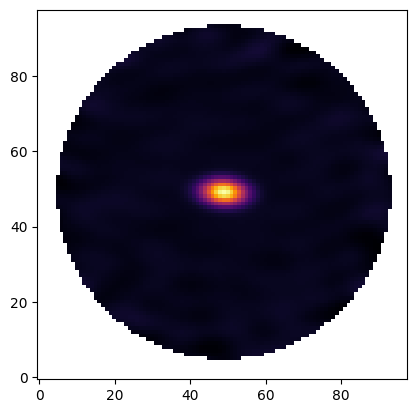

In [88]:
im = plt.imshow(mom0.value, origin='lower', cmap='inferno')